In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
df = pd.read_csv("../data/heart.csv")

In [4]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [8]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='str')

In [9]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [10]:
df.fillna(df.median(numeric_only=True), inplace=True)

df.fillna(df.mode().iloc[0], inplace=True)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True)

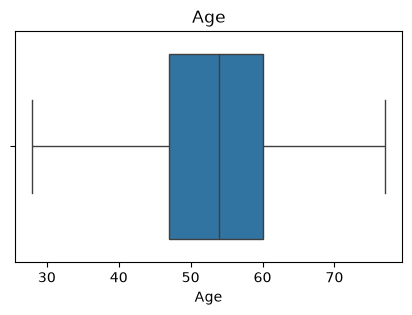

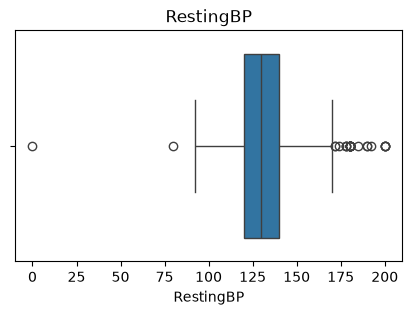

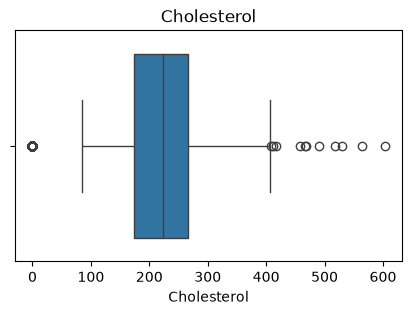

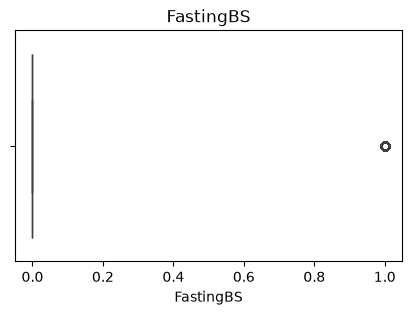

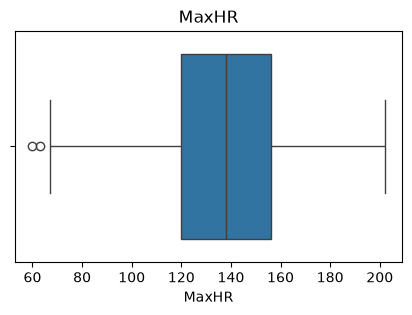

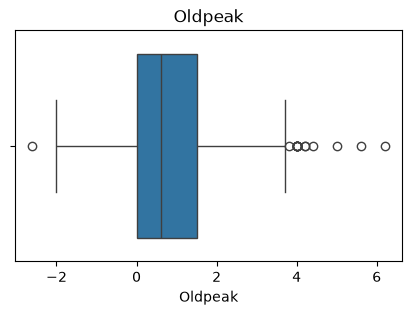

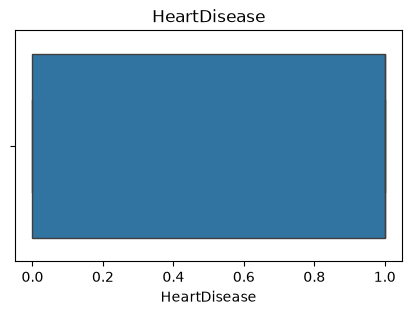

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [14]:
numeric_columns = df.select_dtypes(include=np.number).columns.drop("HeartDisease")

for col in numeric_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [15]:
df.dtypes

Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object

In [16]:
categorical_columns = df.select_dtypes(include="object").columns

df = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

C:\Users\navin\AppData\Local\Temp\ipykernel_25456\1403314280.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include="object").columns


In [21]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier

from sklearn.metrics import accuracy_score

In [26]:
accuracy = {}

In [27]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy["Logistic Regression"] = accuracy_score(y_test, y_pred)

print("Logistic Regression Accuracy:", accuracy["Logistic Regression"])

Logistic Regression Accuracy: 0.864406779661017


In [28]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

accuracy["KNN"] = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy["KNN"])

KNN Accuracy: 0.8389830508474576


In [30]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

accuracy["SVM"] = accuracy_score(y_test, y_pred)

print("SVM Accuracy:", accuracy["SVM"])

SVM Accuracy: 0.847457627118644


In [31]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred = dt.predict(X_test)

accuracy["Decision Tree"] = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy["Decision Tree"])

Decision Tree Accuracy: 0.8135593220338984


In [32]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

accuracy["Random Forest"] = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy["Random Forest"])

Random Forest Accuracy: 0.8220338983050848


In [ ]:
df.fillna(...)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,True,True,False,False,True,False,False,False,True
1,49,160,180,0,156,1.0,1,False,False,True,False,True,False,False,True,False
2,37,130,283,0,98,0.0,0,True,True,False,False,False,True,False,False,True
3,48,138,214,0,108,1.5,1,False,False,False,False,True,False,True,True,False
4,54,150,195,0,122,0.0,0,True,False,True,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
912,57,140,241,0,123,0.2,1,False,False,False,False,True,False,True,True,False
913,45,110,264,0,132,1.2,1,True,False,False,True,True,False,False,True,False
915,57,130,131,0,115,1.2,1,True,False,False,False,True,False,True,True,False
916,57,130,236,0,174,0.0,1,False,True,False,False,False,False,False,True,False


In [34]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

accuracy["Gradient Boosting"] = accuracy_score(y_test, y_pred)

print("Gradient Boosting Accuracy:", accuracy["Gradient Boosting"])

Gradient Boosting Accuracy: 0.8728813559322034


In [35]:
accuracy_df = pd.DataFrame(
    accuracy.items(),
    columns=["Algorithm", "Accuracy"]
)

accuracy_df = accuracy_df.sort_values(
    by="Accuracy",
    ascending=False
)

accuracy_df

,Algorithm,Accuracy
6,Gradient Boosting,0.872881
5,Naive Bayes,0.864407
0,Logistic Regression,0.864407
2,SVM,0.847458
1,KNN,0.838983
4,Random Forest,0.822034
3,Decision Tree,0.813559


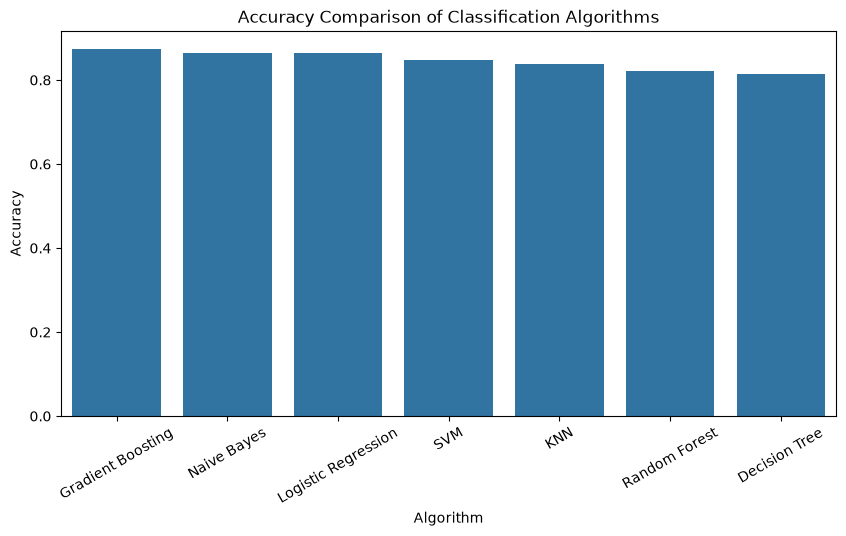

In [36]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Algorithm",
    y="Accuracy",
    data=accuracy_df
)

plt.xticks(rotation=30)

plt.title("Accuracy Comparison of Classification Algorithms")

plt.show()

In [37]:
best_model = accuracy_df.iloc[0]

print("Best Algorithm :", best_model["Algorithm"])
print("Highest Accuracy :", round(best_model["Accuracy"] * 100, 2), "%")

Best Algorithm : Gradient Boosting
Highest Accuracy : 87.29 %


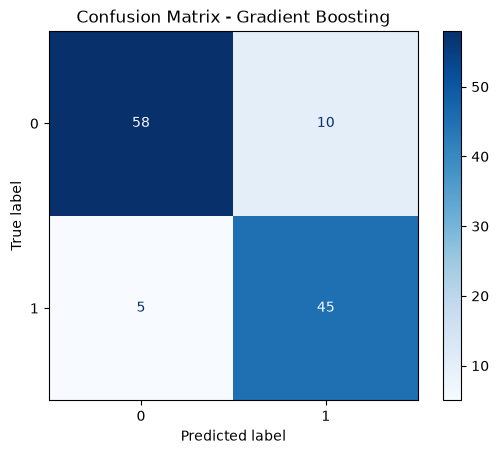

In [38]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Gradient Boosting")
plt.show()

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.85      0.89        68
           1       0.82      0.90      0.86        50

    accuracy                           0.87       118
   macro avg       0.87      0.88      0.87       118
weighted avg       0.88      0.87      0.87       118



In [ ]:
df.isnull().sum()

Age                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
Oldpeak              0
HeartDisease         0
Sex_M                0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_Normal    0
RestingECG_ST        0
ExerciseAngina_Y     0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64